In [1]:
# Importing the necessary libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
bank=pd.read_csv('/content/Bank customers.csv')
bank.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [3]:
bank.shape

(10127, 21)

In [4]:
bank.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [5]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

<Axes: xlabel='Customer_Age'>

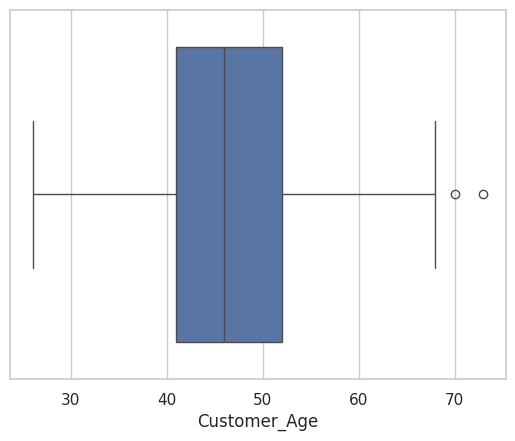

In [6]:
sns.set_theme(style='whitegrid')
sns.boxplot(x=bank['Customer_Age'])

# Most of the customer are somewhere near 45 years of age, some outlier that are depicted by the dots on the right side at the age 70 and maybe 75

In [7]:
bank[['Gender','Credit_Limit']].groupby('Gender').agg(['mean','count'])

Credit_Limit      
                mean count
Gender                    
F        5023.854274  5358
M       12685.674963  4769

In [8]:
bank[['Gender','Avg_Utilization_Ratio']].groupby('Gender').agg(['mean','median'])

Avg_Utilization_Ratio       
                        mean median
Gender                             
F                   0.341957  0.304
M                   0.199548  0.100

In [9]:
bank_cards=bank.groupby('Card_Category')
bank_cards['Customer_Age'].max()

,Customer_Age
Card_Category,
Blue,73
Gold,63
Platinum,56
Silver,65


In [10]:
bank_cards=bank.groupby('Card_Category')
bank_cards['Customer_Age'].min()

,Customer_Age
Card_Category,
Blue,26
Gold,29
Platinum,39
Silver,26


In [11]:
bank_cards['Avg_Utilization_Ratio'].mean()

,Avg_Utilization_Ratio
Card_Category,
Blue,0.290859
Gold,0.057103
Platinum,0.043650
Silver,0.057310


In [12]:
bank_marital=bank.groupby('Marital_Status')

In [13]:
bank_marital['Card_Category'].value_counts()

Marital_Status  Card_Category
Divorced        Blue              696
                Silver             46
                Gold                5
                Platinum            1
Married         Blue             4433
                Silver            206
                Gold               41
                Platinum            7
Single          Blue             3624
                Silver            251
                Gold               58
                Platinum           10
Unknown         Blue              683
                Silver             52
                Gold               12
                Platinum            2
Name: count, dtype: int64

In [14]:
# Now lets move forward and see if we have categorical data in our dataset
bank.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [15]:
bank['Attrition_Flag'].value_counts()

,count
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


In [16]:
bank['Education_Level'].value_counts()

,count
Education_Level,
Graduate,3128
High School,2013
Unknown,1519
Uneducated,1487
College,1013
Post-Graduate,516
Doctorate,451


In [17]:
def ref1(x):
    if x=='M':
      return 1
    else:
      return 0

bank['Gender']=bank['Gender'].map(ref1)

In [18]:
bank['Gender'].value_counts()

,count
Gender,
0,5358
1,4769


In [19]:
def ref2(x):
    if x=='Existing Customer':
      return 1
    else:
      return 0

bank['Attrition_Flag']=bank['Attrition_Flag'].map(ref2)


In [20]:
bank['Attrition_Flag'].value_counts()

,count
Attrition_Flag,
1,8500
0,1627


In [21]:
bank.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,1,45,1,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,1,49,0,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,1,51,1,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,1,40,0,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,1,40,1,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [22]:
# Converting categorical data into numerical data
y=bank['Card_Category']
x=bank.copy()

In [23]:
x['Income_Category'].value_counts()

,count
Income_Category,
Less than $40K,3561
$40K - $60K,1790
$80K - $120K,1535
$60K - $80K,1402
Unknown,1112
$120K +,727


In [24]:
from sklearn.preprocessing import LabelEncoder

def label_encoder(feat):
  le=LabelEncoder()
  le.fit(feat)
  print(feat.name,le.classes_)
  return le.transform(feat)

In [25]:
x['Income_Category']=label_encoder(x['Income_Category'])
x.head()

Income_Category ['$120K +' '$40K - $60K' '$60K - $80K' '$80K - $120K' 'Less than $40K'
 'Unknown']


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,1,45,1,3,High School,Married,2,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,1,49,0,5,Graduate,Single,4,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,1,51,1,3,Graduate,Married,3,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,1,40,0,4,High School,Unknown,4,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,1,40,1,3,Uneducated,Married,2,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [26]:
x['Income_Category'].value_counts()

,count
Income_Category,
4,3561
1,1790
3,1535
2,1402
5,1112
0,727


In [27]:
x['Education_Level']=label_encoder(x['Education_Level'])
x.head()

Education_Level ['College' 'Doctorate' 'Graduate' 'High School' 'Post-Graduate'
 'Uneducated' 'Unknown']


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,1,45,1,3,3,Married,2,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,1,49,0,5,2,Single,4,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,1,51,1,3,2,Married,3,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,1,40,0,4,3,Unknown,4,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,1,40,1,3,5,Married,2,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [28]:
x['Marital_Status']=label_encoder(x['Marital_Status'])
x.head()

Marital_Status ['Divorced' 'Married' 'Single' 'Unknown']


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,1,45,1,3,3,1,2,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,1,49,0,5,2,2,4,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,1,51,1,3,2,1,3,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,1,40,0,4,3,3,4,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,1,40,1,3,5,1,2,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [29]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  int64  
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  int64  
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  int64  
 6   Marital_Status            10127 non-null  int64  
 7   Income_Category           10127 non-null  int64  
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [30]:
x=x.drop(['CLIENTNUM','Card_Category'],axis=1)
x.shape

(10127, 19)

In [31]:
y.value_counts()

,count
Card_Category,
Blue,9436
Silver,555
Gold,116
Platinum,20


In [32]:
y=bank[['Card_Category']]
y['Card_Category']=label_encoder(y['Card_Category'])
y.head()

Card_Category ['Blue' 'Gold' 'Platinum' 'Silver']


,Card_Category
0,0
1,0
2,0
3,0
4,0


In [33]:
y.value_counts()

,count
Card_Category,
0,9436
3,555
1,116
2,20


In [34]:
x.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,1,45,1,3,3,1,2,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,1,49,0,5,2,2,4,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,1,51,1,3,2,1,3,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,1,40,0,4,3,3,4,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,1,40,1,3,5,1,2,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [35]:
x.describe()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,0.839340,46.325960,0.470919,2.346203,3.096574,1.463415,2.863928,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,0.367235,8.016814,0.499178,1.298908,1.834812,0.737808,1.504700,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,1.000000,41.000000,0.000000,1.000000,2.000000,1.000000,2.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,1.000000,46.000000,0.000000,2.000000,3.000000,1.000000,3.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,1.000000,52.000000,1.000000,3.000000,5.000000,2.000000,4.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,1.000000,73.000000,1.000000,5.000000,6.000000,3.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


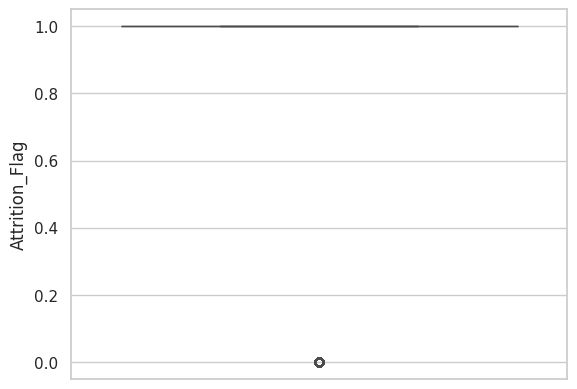

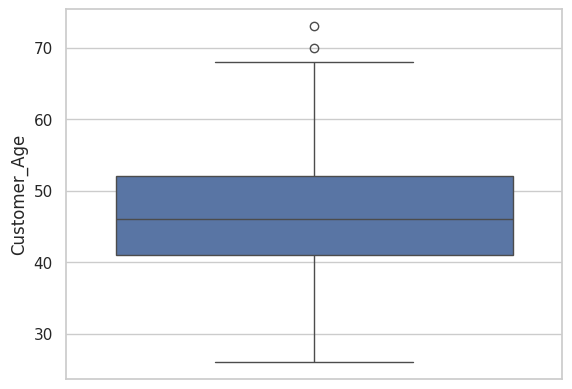

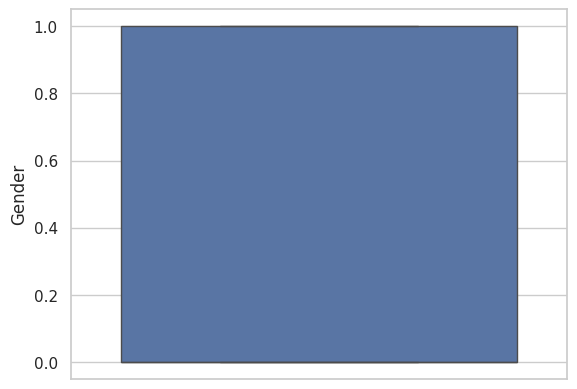

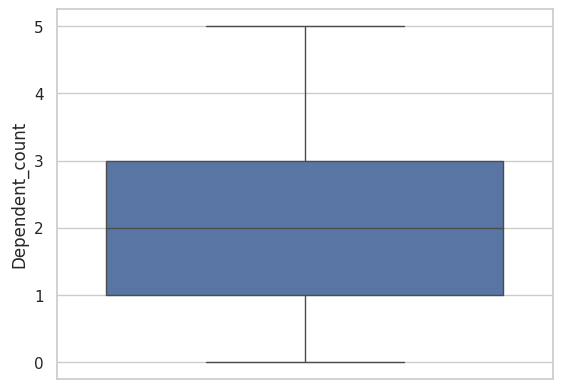

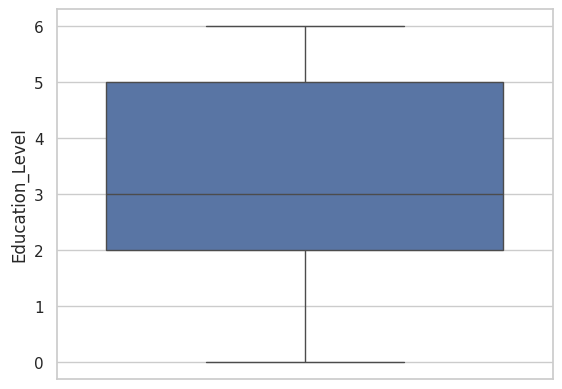

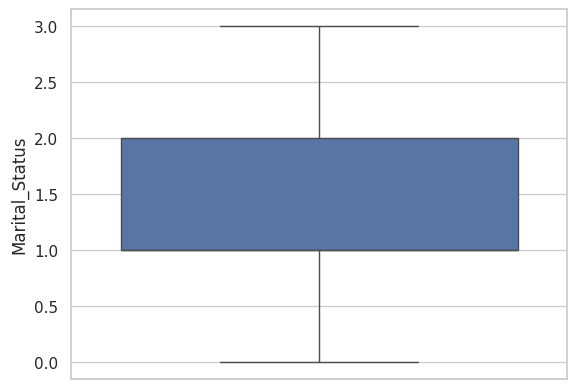

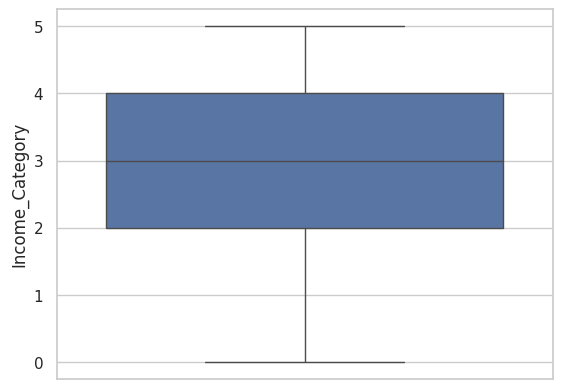

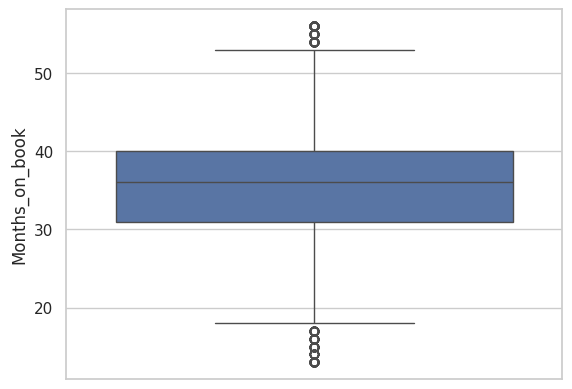

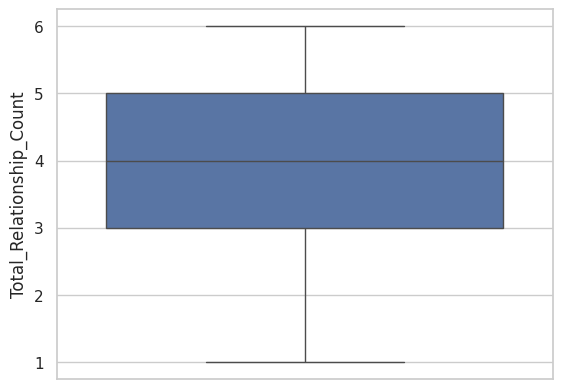

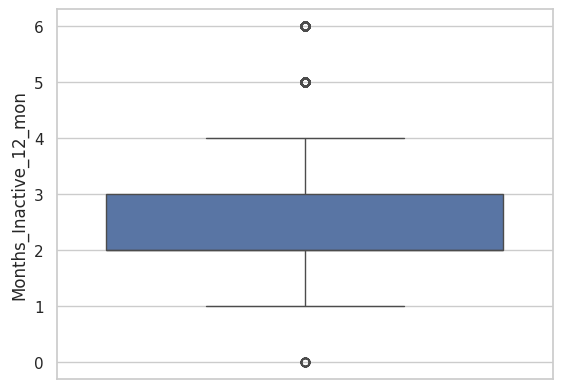

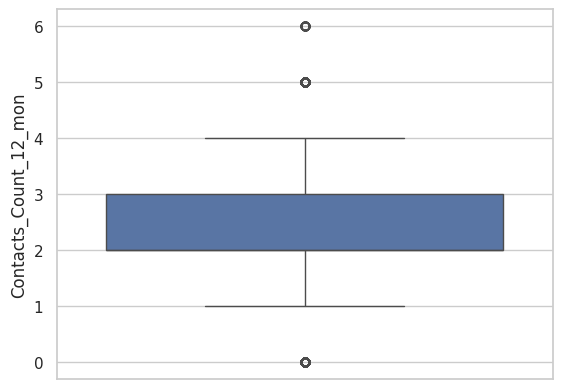

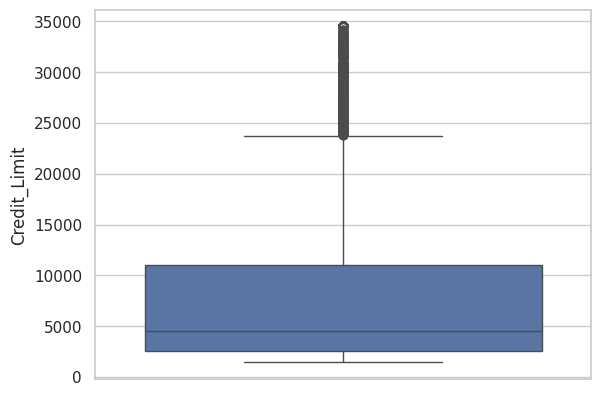

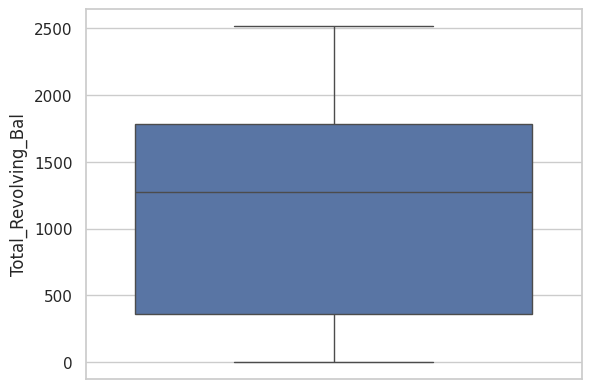

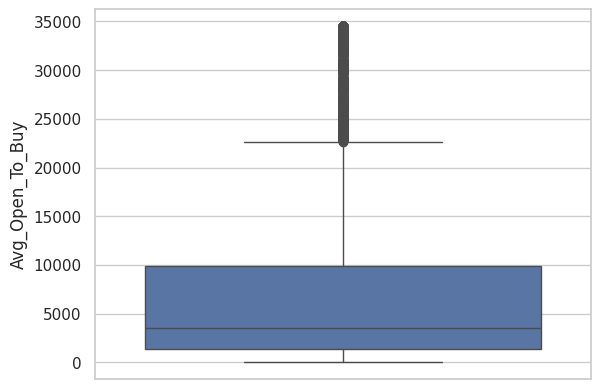

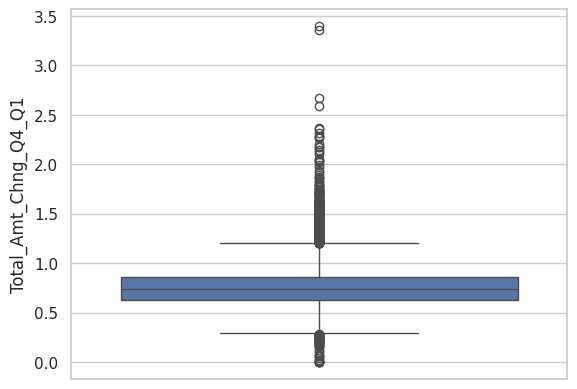

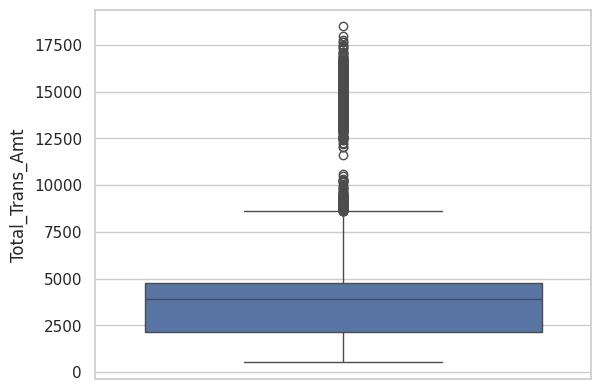

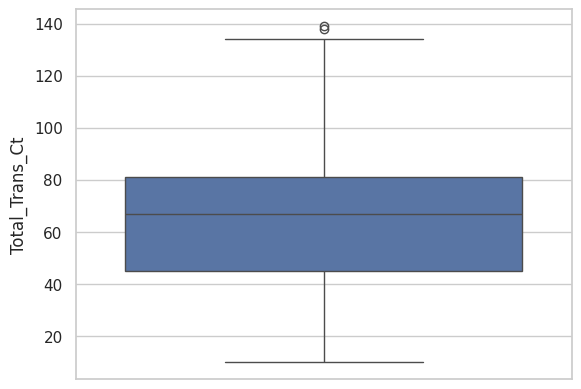

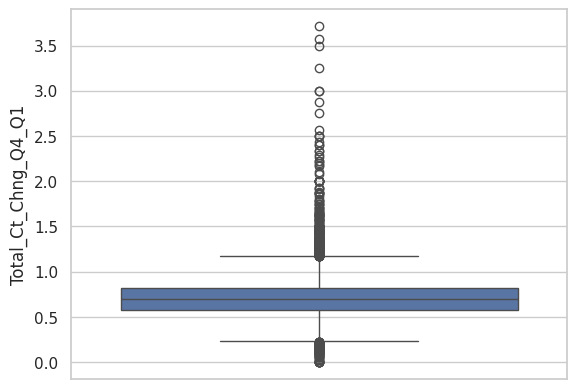

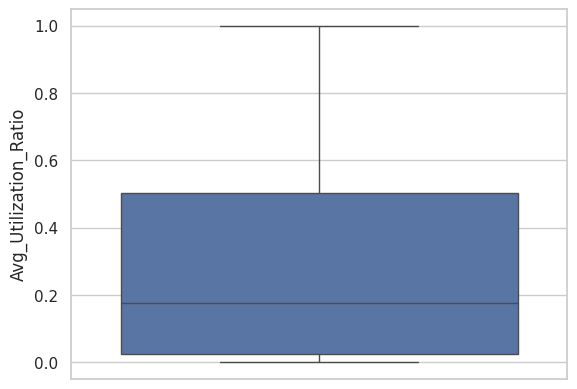

In [36]:
# Outlier Detection
def boxplots(col):
  sns.boxplot(x[col])
  plt.show()

for i in list(x.select_dtypes(exclude=['object']).columns):
  boxplots(i)

In [37]:
Q1=x.quantile(0.25)
Q3=x.quantile(0.75)
IQR=Q3-Q1
UL=Q3+1.5*IQR
LL=Q1-1.5*IQR
print(UL)
print(LL)

Attrition_Flag                  1.000
Customer_Age                   68.500
Gender                          2.500
Dependent_count                 6.000
Education_Level                 9.500
Marital_Status                  3.500
Income_Category                 7.000
Months_on_book                 53.500
Total_Relationship_Count        8.000
Months_Inactive_12_mon          4.500
Contacts_Count_12_mon           4.500
Credit_Limit                23836.250
Total_Revolving_Bal          3921.500
Avg_Open_To_Buy             22660.750
Total_Amt_Chng_Q4_Q1            1.201
Total_Trans_Amt              8619.250
Total_Trans_Ct                135.000
Total_Ct_Chng_Q4_Q1             1.172
Avg_Utilization_Ratio           1.223
dtype: float64
Attrition_Flag                  1.000
Customer_Age                   24.500
Gender                         -1.500
Dependent_count                -2.000
Education_Level                -2.500
Marital_Status                 -0.500
Income_Category                -1.0

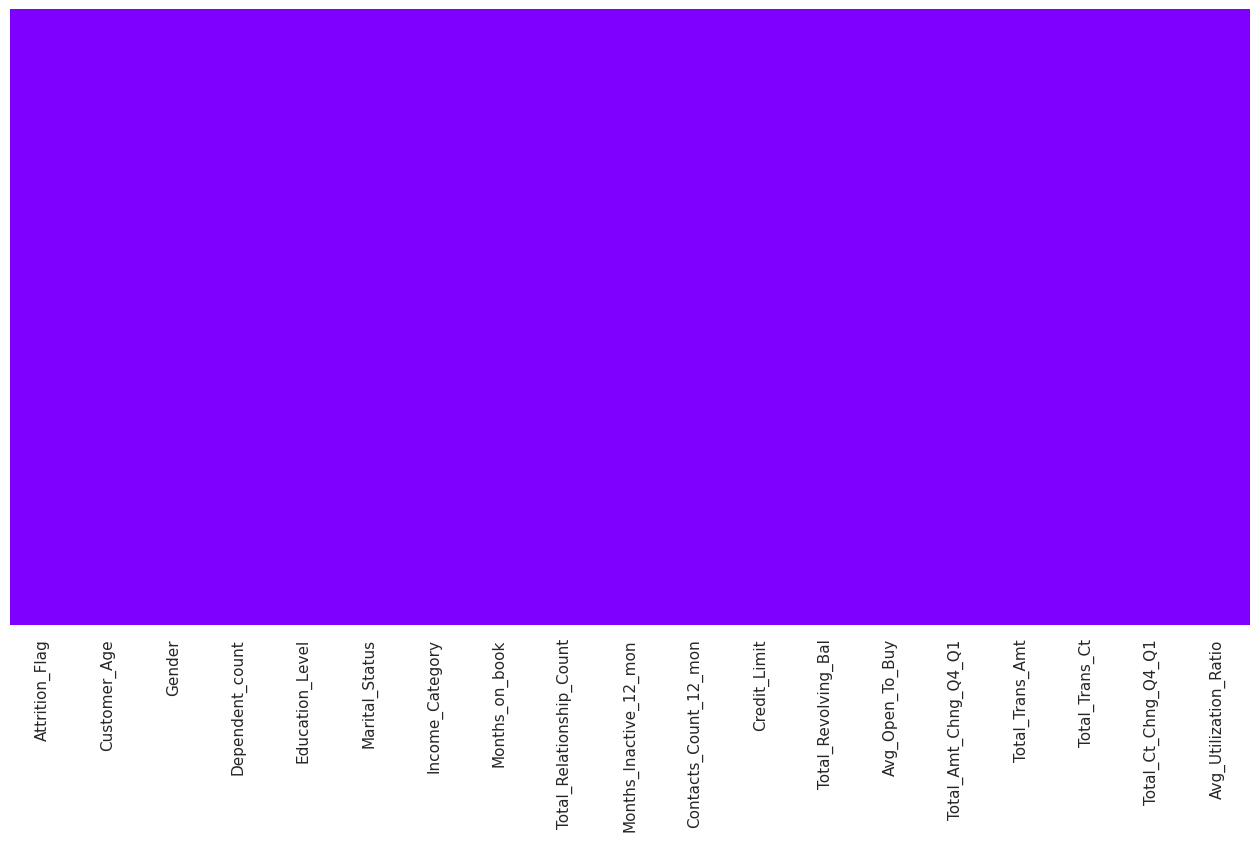

In [42]:
plt.figure(figsize=(16,8))
sns.heatmap(x.isnull(),cbar=False,cmap='rainbow',yticklabels=False)
plt.show()

In [43]:
# Applying capping method by using KNN Imputation
from sklearn.impute import KNNImputer
imputer=KNNImputer()
x_impute=pd.DataFrame(imputer.fit_transform(x),columns=x.columns)
x_impute

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,1.0,45.0,1.0,3.0,3.0,1.0,2.0,39.0,5.0,1.0,3.0,12691.0,777.0,11914.0,1.335,1144.0,42.0,1.625,0.061
1,1.0,49.0,0.0,5.0,2.0,2.0,4.0,44.0,6.0,1.0,2.0,8256.0,864.0,7392.0,1.541,1291.0,33.0,3.714,0.105
2,1.0,51.0,1.0,3.0,2.0,1.0,3.0,36.0,4.0,1.0,0.0,3418.0,0.0,3418.0,2.594,1887.0,20.0,2.333,0.000
3,1.0,40.0,0.0,4.0,3.0,3.0,4.0,34.0,3.0,4.0,1.0,3313.0,2517.0,796.0,1.405,1171.0,20.0,2.333,0.760
4,1.0,40.0,1.0,3.0,5.0,1.0,2.0,21.0,5.0,1.0,0.0,4716.0,0.0,4716.0,2.175,816.0,28.0,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,1.0,50.0,1.0,2.0,2.0,2.0,1.0,40.0,3.0,2.0,3.0,4003.0,1851.0,2152.0,0.703,15476.0,117.0,0.857,0.462
10123,0.0,41.0,1.0,2.0,6.0,0.0,1.0,25.0,4.0,2.0,3.0,4277.0,2186.0,2091.0,0.804,8764.0,69.0,0.683,0.511
10124,0.0,44.0,0.0,1.0,3.0,1.0,4.0,36.0,5.0,3.0,4.0,5409.0,0.0,5409.0,0.819,10291.0,60.0,0.818,0.000
10125,0.0,30.0,1.0,2.0,2.0,3.0,1.0,36.0,4.0,3.0,3.0,5281.0,0.0,5281.0,0.535,8395.0,62.0,0.722,0.000


In [44]:
x_impute.isnull().sum().sum()

np.int64(0)

In [45]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=pd.DataFrame(scaler.fit_transform(x_impute),columns=x_impute.columns)

In [46]:
x_scaled

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0.437506,-0.165406,1.059956,0.503368,-0.052637,-0.628128,-0.574182,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,2.623494,-0.959707,-0.973895,3.834003,-0.775882
1,0.437506,0.333570,-0.943436,2.043199,-0.597678,0.727306,0.755053,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,3.563293,-0.916433,-1.357340,12.608573,-0.616276
2,0.437506,0.583058,1.059956,0.503368,-0.597678,-0.628128,0.090436,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,8.367214,-0.740982,-1.911206,6.807864,-0.997155
3,0.437506,-0.789126,-0.943436,1.273283,-0.052637,2.082739,0.755053,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,2.942843,-0.951758,-1.911206,6.807864,1.759686
4,0.437506,-0.789126,1.059956,0.503368,1.037447,-0.628128,-0.574182,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,6.455682,-1.056263,-1.570365,7.509325,-0.997155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0.437506,0.458314,1.059956,-0.266547,-0.597678,0.727306,-1.238799,0.509840,-0.522785,-0.337598,0.492404,-0.509330,0.844455,-0.584929,-0.259771,3.259358,2.221481,0.608119,0.678714
10123,-2.285681,-0.664382,1.059956,-0.266547,1.582489,-1.983561,-1.238799,-1.368442,0.120579,-0.337598,0.492404,-0.479181,1.255524,-0.591639,0.201004,1.283475,0.176440,-0.122745,0.856458
10124,-2.285681,-0.290150,-0.943436,-1.036462,-0.052637,-0.628128,0.755053,0.008965,0.763943,0.651940,1.396424,-0.354626,-1.426858,-0.226632,0.269436,1.732994,-0.207005,0.444305,-0.997155
10125,-2.285681,-2.036565,1.059956,-0.266547,-0.597678,2.082739,-1.238799,0.008965,0.120579,0.651940,0.492404,-0.368710,-1.426858,-0.240713,-1.026208,1.174848,-0.121795,0.041070,-0.997155


In [47]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=101,
                                               stratify=y)


# **Building ensemble model**

In [48]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [49]:
f_df=pd.DataFrame({"feature":x_train.columns,'rf_importance':rf.feature_importances_}).sort_values(by='rf_importance',
                                                                                                 ascending=False)

In [50]:
f_df

,feature,rf_importance
11,Credit_Limit,0.183529
13,Avg_Open_To_Buy,0.177577
6,Income_Category,0.124325
15,Total_Trans_Amt,0.061256
18,Avg_Utilization_Ratio,0.053545
16,Total_Trans_Ct,0.048601
14,Total_Amt_Chng_Q4_Q1,0.043400
17,Total_Ct_Chng_Q4_Q1,0.041919
12,Total_Revolving_Bal,0.041495
1,Customer_Age,0.038666


In [51]:
pred_train_rf=rf.predict(x_train)
pred_test_rf=rf.predict(x_test)

In [52]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [53]:
print("**********************************************")
print(confusion_matrix(y_train,pred_train_rf))
print("**********************************************")
print(confusion_matrix(y_test,pred_test_rf))

**********************************************
[[7548    0    0    0]
 [   0   93    0    0]
 [   0    0   16    0]
 [   0    0    0  444]]
**********************************************
[[1867    2    0   19]
 [   7    4    0   12]
 [   1    1    0    2]
 [  45    0    0   66]]


In [55]:
print("**********************************************")
print(classification_report(y_train,pred_train_rf))
print("**********************************************")
print(classification_report(y_test,pred_test_rf))

**********************************************
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7548
           1       1.00      1.00      1.00        93
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00       444

    accuracy                           1.00      8101
   macro avg       1.00      1.00      1.00      8101
weighted avg       1.00      1.00      1.00      8101

**********************************************
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1888
           1       0.57      0.17      0.27        23
           2       0.00      0.00      0.00         4
           3       0.67      0.59      0.63       111

    accuracy                           0.96      2026
   macro avg       0.55      0.44      0.47      2026
weighted avg       0.95      0.96      0.95      2026



In [56]:
print("**********************************************")
print(accuracy_score(y_train,pred_train_rf))
print("**********************************************")
print(accuracy_score(y_test,pred_test_rf))

**********************************************
1.0
**********************************************
0.956071076011846


# **Random Forest Classifier with recursive feature techniques**

In [57]:
from sklearn.feature_selection import RFE
rf1=RandomForestClassifier()
feature_1=RFE(estimator=rf1,n_features_to_select=17,step=1)
feature_1=feature_1.fit(x_train,y_train)

In [58]:
pred_train_rf1=feature_1.predict(x_train)
pred_test_rf1=feature_1.predict(x_test)

In [59]:
print("**********************************************")
print(accuracy_score(y_train,pred_train_rf1))
print("**********************************************")
print(accuracy_score(y_test,pred_test_rf1))

**********************************************
1.0
**********************************************
0.9580454096742349


In [60]:
# Cross validation method
from sklearn.model_selection import cross_val_score
rf_rfe_training=cross_val_score(feature_1,x_train,y_train,cv=10)
print(rf_rfe_training)
print()
print(rf_rfe_training.mean())

[0.9568434  0.94320988 0.96049383 0.95555556 0.9654321  0.95802469
 0.95802469 0.95679012 0.96790123 0.9654321 ]

0.9587707600736781


# PCA Method**

In [62]:
from sklearn.decomposition import PCA
pca=PCA(n_components=10)
pca_fit=pca.fit_transform(x_scaled)

In [63]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(pca_fit,y,test_size=0.2,random_state=101,
                                               stratify=y)


In [64]:
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier()
gb.fit(x_train,y_train)

GradientBoostingClassifier()

In [65]:
pred_train_gb=gb.predict(x_train)
pred_test_gb=gb.predict(x_test)

In [66]:
print("**********************************************")
print(accuracy_score(y_train,pred_train_gb))
print("**********************************************")
print(accuracy_score(y_test,pred_test_gb))

**********************************************
0.9642019503764967
**********************************************
0.9318854886475815
